In [1]:
import numpy as np
import imageio.v3 as io
import matplotlib.pyplot as plt
import pandas as pd
from concurrent.futures import ThreadPoolExecutor

In [2]:
from lib.database import Database
from lib.domain import Feature, ImageRecord
from lib.features.haralick import HaralickFeatureExtractor
from lib.features.lbp import LBPFeatureExtractor
from lib.features.colors import ColorsFeatureExtractor
from lib.features.hog import HoGFeatureExtractor
from lib.features.log import LoGFeatureExtractor
from lib.features.bovw import BoVW

### Dataset dos pets

In [3]:
# DB para as features
db = Database()

df = pd.read_csv("./data/metadata.csv")
df.head()

,class_id,class_name,filename
0,0,simba,simba/00000.jpg
1,0,simba,simba/00001.jpg
2,0,simba,simba/00002.jpg
3,0,simba,simba/00003.jpg
4,0,simba,simba/00004.jpg


### Criação da BoVW

In [4]:
# BoVW usando HoG como extrator
bovw = BoVW(HoGFeatureExtractor.apply, size=32, n_clusters=16)

# Preenchendo o dicionario
for index, row in df.iterrows():
    img = io.imread(f"./data/{row["filename"]}")
    bovw.add_image(img)
    
# Aplicação dos clusters
bovw.compute()

### Extração de features

In [5]:
def extract_features(img: np.ndarray) -> Feature:
    hal = HaralickFeatureExtractor.apply(img)
    lbp = LBPFeatureExtractor.apply(img)
    colors = ColorsFeatureExtractor.apply(img)
    hog = HoGFeatureExtractor.apply(img)
    log = LoGFeatureExtractor.apply(img)
    
    # Vetor de features
    features = np.concatenate((hal, lbp, colors, hog, log, bovw.apply(img)))
    
    return features / (np.linalg.norm(features) + 1e-10)

In [6]:
def worker(r: pd.Series) -> ImageRecord:
    img = io.imread(f"./data/{r["filename"]}")
    features = extract_features(img)
    
    return ImageRecord(
        r["class_name"],
        r["filename"],
        features
    )
    
with ThreadPoolExecutor(max_workers=5) as ex:
    results = ex.map(worker, [row for index, row in df.iterrows()])
    for result in results:
        db.insert(result)


### Busca

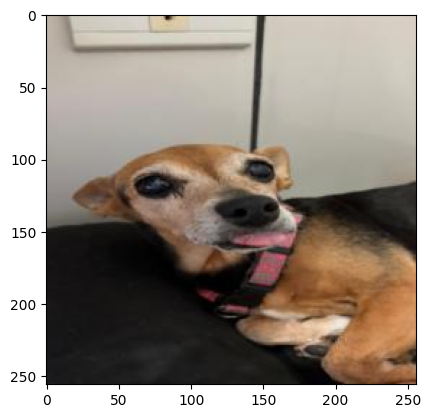

In [13]:
# Imagem para buscar
target = io.imread("./data/kyara/00115.jpg")
vec = extract_features(target)
plt.imshow(target)

In [14]:
results = db.search(vec)

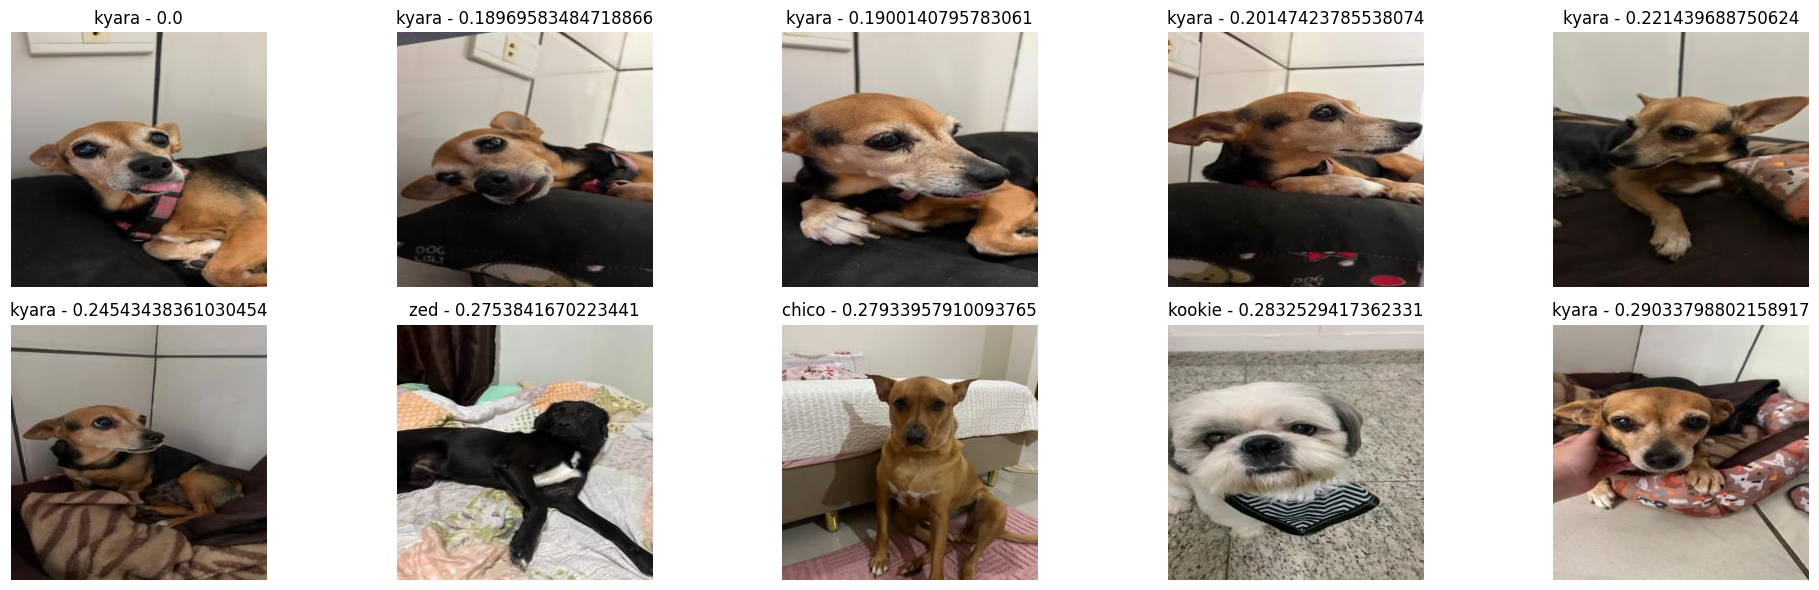

In [15]:
# Exibir resultados encontreados
# (já estão ordenados por distancia)
fig, axes = plt.subplots(2, 5, figsize=(20, 6))
axes = axes.flatten()

for ax, res in zip(axes, results):
    img = io.imread(f"./data/{res.url}")

    ax.imshow(img, cmap="gray")
    ax.set_title(f"{res.name} - {res.distance}")
    ax.axis("off")

plt.tight_layout()
plt.show()